In [1]:
from IPython.display import HTML
display(HTML('<style>' + open('../assets/custom_styles.css').read() + '</style>'))

<p style="text-align: center"><img src="../assets/img/amazinum.png" width="180"></p>

# Hometask: Linear Regression one variable

In [2]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np 

from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

In [3]:
%matplotlib inline

In [4]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [5]:
df = pd.DataFrame(data, columns=['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'])
y_series = target

df = df[['RM']] 
df['target'] = y_series

# Review the data
print (df.head(10))
df.describe ()

      RM  target
0  6.575    24.0
1  6.421    21.6
2  7.185    34.7
3  6.998    33.4
4  7.147    36.2
5  6.430    28.7
6  6.012    22.9
7  6.172    27.1
8  5.631    16.5
9  6.004    18.9


,RM,target
count,506.000000,506.000000
mean,6.284634,22.532806
std,0.702617,9.197104
min,3.561000,5.000000
25%,5.885500,17.025000
50%,6.208500,21.200000
75%,6.623500,25.000000
max,8.780000,50.000000


<Axes: xlabel='RM', ylabel='target'>

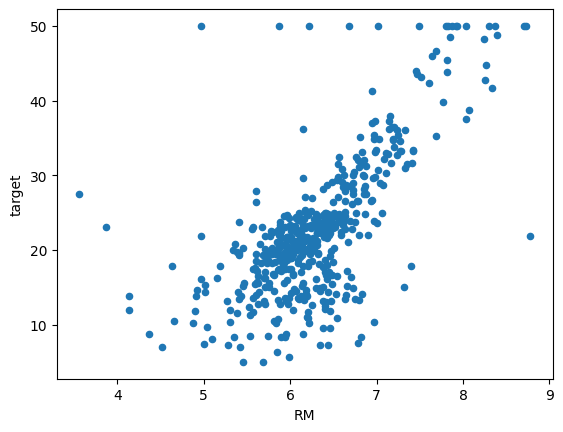

In [6]:
df.plot.scatter('RM', 'target')

In [7]:
X = data[:, 5]
X = X.reshape(-1,1) 
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.25, random_state=2018)

print(f'X_train.shape = {X_train.shape}')
print(f'y_train.shape = {y_train.shape}')

X_train.shape = (379, 1)
y_train.shape = (379,)


In [8]:
class Linear_Regression_1():
    def __init__(self):
        pass

    def h(self, b, w, X):
        '''
        :param b - зсув (intercept), число
        :param w - ваги (coef), масив форми [1, n]
        :param X - дані, масив форми [m, n]
        '''
        
        assert (X.shape[1] == w.shape[1])
        h_res = np.dot(X, w.T) + b

        return h_res

# Check result
np.random.seed(2018)
b_check = np.random.randn()
w_check = np.random.randn(1,1)
X_check = np.random.randn(10,1)

lin_reg_1 = Linear_Regression_1()
result = lin_reg_1.h(b_check, w_check, X_check)
print(result)

[[ 0.97328067]
 [-1.02123839]
 [ 0.01548272]
 [ 0.22131391]
 [-0.35985014]
 [-0.21271821]
 [-0.67711878]
 [-0.0244979 ]
 [ 0.02010501]
 [-0.37284922]]


In [9]:
class Linear_Regression_2():
    def __init__(self):
        pass

    def J (self, h, y):
        '''
        :param h - передбачені значення, масив форми (m, 1)
        :param y - реальні ціни, масив форми (m, 1)
        :return - значення функції втрат (число)
        '''
        if h.shape != y.shape:
            raise Exception('Перевірте твердження в J: форми h та y повинні збігатися')

        m = h.shape[0] # кількість рядків
        err = h - y
        J_res = np.sum(err**2) / (2 * m)

        return J_res

# Check result
np.random.seed(2019)
m = 10 
y_check = np.random.randn(m,1)
h_check = np.random.randn(m,1)

lin_reg_2 = Linear_Regression_2()
print(f'Результат J: {lin_reg_2.J(h_check, y_check)}')

Результат J: 0.8971465151865979


In [10]:
class Linear_Regression_3():
    def __init__(self, max_iter = 1e5, alpha = 1, eps = 1e-10, verbose= 0):
        pass

    def h(self, b, w, X):
        return np.dot(X, w.T) + b # це з першої функції

    def J_derivative(self, params, X, y):
        b, w = params
        self.m = X.shape[0] # кількість зразків
        self.n = X.shape[1] # кількість ознак

        h_val = self.h(b, w, X)

        error = h_val - y # значення помилки
        dJ_b = np.sum(error) / self.m # середнє значення помилки
        dJ_w = np.dot(error.T, X) / self.m # матричне множення

        return (dJ_b, dJ_w)

# Check result
np.random.seed(2020)
m, n = 10, 1
X_check = np.random.randn(m, n)
y_check = np.random.randn(m, 1)
b_check = np.random.randn()
w_check = np.random.randn(1, n)
params = (b_check, w_check)

lin_reg_3 = Linear_Regression_3()
lin_reg_3.m, lin_reg_3.n = m, n
print(lin_reg_3.J_derivative(params, X_check, y_check))

(np.float64(2.190460881995871), array([[-1.43284262]]))


In [11]:
class Linear_Regression_4():
    def __init__(self, max_iter = 1e5, alpha = 0.01, eps = 1e-10, verbose= 0):
        self.max_iter = max_iter
        self.alpha = alpha
        self.eps = eps
        self.verbose = verbose

    # Перша функція Гіпотеза (h)
    def h(self, b, w, X):
        return np.dot(X, w.T) + b

    # Друга функція втрат
    def J (self, h, y):
        m = h.shape[0] 
        err = h - y
        return np.sum(err**2) / (2 * m)

    # Третя функція обчислює градієнти
    def J_derivative(self, params, X, y):
        b, w = params
        m = X.shape[0] 
        h_val = self.h(b, w, X)
        error = h_val - y 
        dJ_b = np.sum(error) / m 
        dJ_w = np.dot(error.T, X) / m
        return (dJ_b, dJ_w)
        
    def fit(self, X, y):
        self.m, self.n = X.shape
        y = y.reshape(self.m, 1)
        b = 0
        w = np.zeros(self.n).reshape(1, -1)
        params = (b, w)

        print(f"Running gradient descent with alpha = {self.alpha}, eps= {self.eps}, max_iter= {self.max_iter}")
        
        self.J_hist = [-1]
        continue_iter = True
        iter_number = 0

        while continue_iter:
            dJ_b, dJ_w = self.J_derivative(params, X, y) # похідні

            # крок градієнтного спуску
            b = b - self.alpha * dJ_b
            w = w - self.alpha * dJ_w
            params = (b, w)
            
            current_J = self.J(self.h(b, w, X), y)
            self.J_hist.append(self.J(self.h(b, w, X), y)) # історія помилок

            print(f"b = {b}, w= {w}, J= {current_J}")

            if self.max_iter and iter_number > self.max_iter:
                continue_iter = False
            elif np.abs(self.J_hist[iter_number-1] - self.J_hist[iter_number]) < self.eps:
                continue_iter = False
            iter_number += 1

        self.intercept_, self.coef_ = params        
        return True

# Check result
np.random.seed(2021)
m = 10 
n = 1
X_check = np.random.randn(m, n)
y_check = np.random.randn(m, 1)

lin_reg_4 = Linear_Regression_4(alpha = 1, max_iter = 5, verbose=1)
lin_reg_4.fit(X_check, y_check)

print(f"Фінальна помилка (J): {lin_reg_4.J_hist[-1]}")
print(f"Intercept (b): {lin_reg_4.intercept_}")
print(f"Weights (w): {lin_reg_4.coef_}")

Running gradient descent with alpha = 1, eps= 1e-10, max_iter= 5
b = -0.3669368558728844, w= [[-0.4217246]], J= 0.33976525493056825
b = -0.23643637277401236, w= [[-0.46886908]], J= 0.3278115023016167
b = -0.22184776004990137, w= [[-0.52721539]], J= 0.32509097055150316
b = -0.20379279582278398, w= [[-0.55396166]], J= 0.32428457786538833
b = -0.19551630227029396, w= [[-0.5697399]], J= 0.3240380117126319
b = -0.19063380881762437, w= [[-0.57831305]], J= 0.3239623872203208
b = -0.18798089094052142, w= [[-0.58309057]], J= 0.3239391853771439
Фінальна помилка (J): 0.3239391853771439
Intercept (b): -0.18798089094052142
Weights (w): [[-0.58309057]]


In [12]:
class Linear_Regression():
    def __init__(self, max_iter = 1e5, alpha = 0.01, eps = 1e-10, verbose= 0):
        self.max_iter = max_iter
        self.alpha = alpha
        self.eps = eps
        self.verbose = verbose

    def h(self, b, w, X):
        assert (X.shape[1] == w.shape[1])
        
        h_res = np.dot(X, w.T) + b
        return h_res

    def J (self, h, y):
        if h.shape != y.shape:
            raise Exception('Перевірте твердження в J: форми h та y повинні збігатися')

        m = h.shape[0] # кількість рядків
        err = h - y
        J_res = np.sum(err**2) / (2 * m)

        return J_res

    def J_derivative(self, params, X, y):
        b, w = params
        m = X.shape[0] # кількість зразків

        h_val = self.h(b, w, X)

        error = h_val - y # значення помилки
        dJ_b = np.sum(error) / m # середнє значення помилки
        dJ_w = np.dot(error.T, X) / m # матричне множення

        return (dJ_b, dJ_w)

    def fit(self, X, y):
        self.m, self.n = X.shape
        y = y.reshape(self.m, 1)
        b = 0
        w = np.zeros(self.n).reshape(1, -1)
        params = (b, w)
        
        self.J_hist = [-1]
        continue_iter = True
        iter_number = 0

        while continue_iter:
            dJ_b, dJ_w = self.J_derivative(params, X, y) # похідні

            # крок градієнтного спуску
            b = b - self.alpha * dJ_b
            w = w - self.alpha * dJ_w
            params = (b, w)

            self.J_hist.append(self.J(self.h(b, w, X), y)) # історія помилок

            if self.max_iter and iter_number > self.max_iter:
                continue_iter = False
            elif np.abs(self.J_hist[iter_number-1] - self.J_hist[iter_number]) < self.eps:
                continue_iter = False
            iter_number += 1

        self.intercept_, self.coef_ = params        
        return True

    def draw_cost_changes(self):        
        J_hist = self.J_hist[1:]
        plt.figure()
        plt.scatter(np.arange(0, len(J_hist)), J_hist, s=20, marker='.', c='b')
        plt.xlabel('Iterations')
        plt.ylabel('Cost J')
        plt.title(f'Alpha={self.alpha}, Final J={J_hist[-1]:.4f}')

    def predict(self, X):
        return self.h(self.intercept_, self.coef_, X)
   
    def score(self, X_test, y_test):
        z = self.predict(X_test)
        return r2_score(y_test, z)

X_train.shape=  (379, 1)
y_train.shape=  (379,)
X_train= 
[[6.009]
 [5.648]
 [5.885]
 [8.297]
 [6.471]]
R2 Score = 0.5692448312856233
b: -34.31717906874507, w= [[9.01484243]]


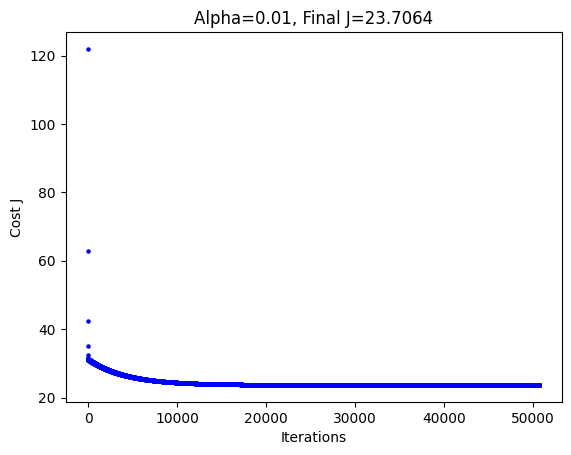

In [13]:
print ('X_train.shape= ',X_train.shape)
print ('y_train.shape= ',y_train.shape)
print ('X_train= \n{}'.format (X_train[:5,:]))
lin_reg = Linear_Regression(alpha= 0.01, verbose=0, eps=1e-8)
lin_reg.fit (X_train, y_train)
lin_reg.draw_cost_changes()
print ('R2 Score =', lin_reg.score(X_test, y_test))
print ('b: {}, w= {}'.format(lin_reg.intercept_, lin_reg.coef_)) 

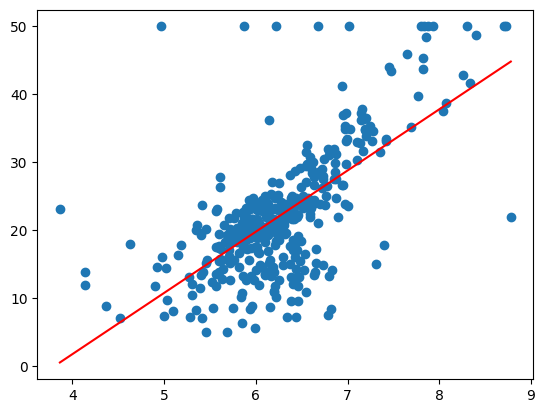

In [14]:
if X_train.shape[1]>1:
    raise Exception ('Select single feature to plot')
plt.figure()
plt.scatter(X_train, y_train)
x_line= np.array([np.min(X_train), np.max(X_train)])
z_line = lin_reg.predict(x_line.reshape(-1,1))
plt.plot(x_line, z_line, '-', c='red')

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

R2 Score = 0.5692590634340771
b: 22.19853298834398, w= [[6.29700244]]


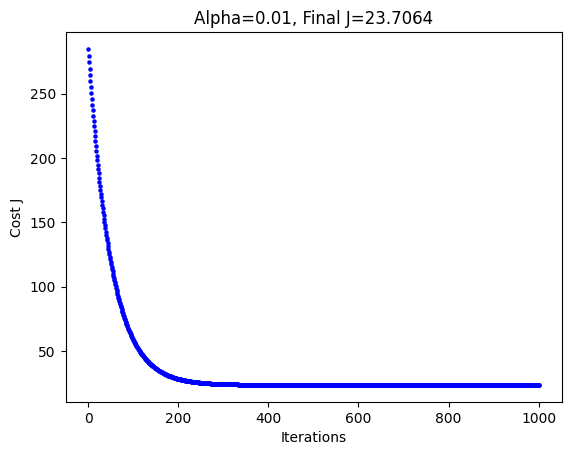

In [16]:
lin_reg = Linear_Regression(alpha= 0.01, verbose=0, eps=1e-8)
lin_reg.fit (X_train_scaled, y_train)
print ('R2 Score =',lin_reg.score(X_test_scaled, y_test))
lin_reg.draw_cost_changes()
print ('b: {}, w= {}'.format(lin_reg.intercept_, lin_reg.coef_))

In [17]:
np.random.seed(2021)

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

X = data
y = target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2018)

print('X_train.shape= ', X_train.shape)
print('y_train.shape= ', y_train.shape)
X_train[:5]

X_train.shape=  (379, 13)
y_train.shape=  (379,)


array([[1.17470e-01, 1.25000e+01, 7.87000e+00, 0.00000e+00, 5.24000e-01,
        6.00900e+00, 8.29000e+01, 6.22670e+00, 5.00000e+00, 3.11000e+02,
        1.52000e+01, 3.96900e+02, 1.32700e+01],
       [1.20482e+01, 0.00000e+00, 1.81000e+01, 0.00000e+00, 6.14000e-01,
        5.64800e+00, 8.76000e+01, 1.95120e+00, 2.40000e+01, 6.66000e+02,
        2.02000e+01, 2.91550e+02, 1.41000e+01],
       [1.28160e-01, 1.25000e+01, 6.07000e+00, 0.00000e+00, 4.09000e-01,
        5.88500e+00, 3.30000e+01, 6.49800e+00, 4.00000e+00, 3.45000e+02,
        1.89000e+01, 3.96900e+02, 8.79000e+00],
       [5.78340e-01, 2.00000e+01, 3.97000e+00, 0.00000e+00, 5.75000e-01,
        8.29700e+00, 6.70000e+01, 2.42160e+00, 5.00000e+00, 2.64000e+02,
        1.30000e+01, 3.84540e+02, 7.44000e+00],
       [8.71675e+00, 0.00000e+00, 1.81000e+01, 0.00000e+00, 6.93000e-01,
        6.47100e+00, 9.88000e+01, 1.72570e+00, 2.40000e+01, 6.66000e+02,
        2.02000e+01, 3.91980e+02, 1.71200e+01]])

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

R2 training Score = 0.7283111795119549
R2 Score = 0.7714399743645594
b: 22.199472295514532, w= [[-6.71888107e-01  1.10023856e+00  4.11947599e-03  8.26282274e-01
  -2.22625058e+00  2.43471682e+00  2.54149326e-01 -3.29472715e+00
   2.45132782e+00 -1.99309805e+00 -1.95019870e+00  7.67364288e-01
  -4.20581658e+00]]


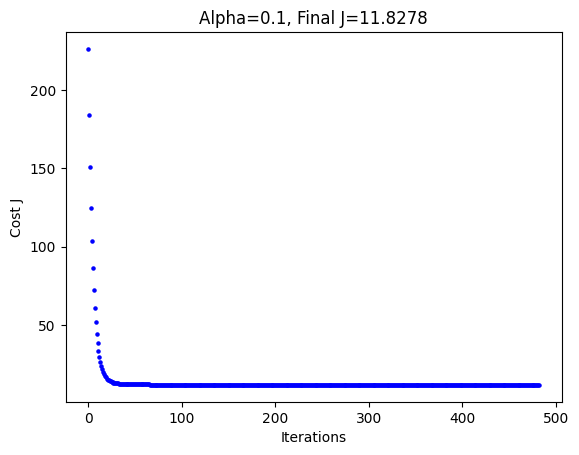

In [19]:
lin_reg = Linear_Regression(alpha= 0.1, verbose=0, eps=1e-5, max_iter=100000)
lin_reg.fit (X_train_scaled, y_train)
lin_reg.draw_cost_changes()
print ('R2 training Score =', lin_reg.score(X_train_scaled, y_train))
print ('R2 Score =', lin_reg.score(X_test_scaled, y_test))
print ('b: {}, w= {}'.format(lin_reg.intercept_, lin_reg.coef_)) 

In [20]:
from sklearn.linear_model import LinearRegression
lin_reg_sklearn = LinearRegression().fit(X_train_scaled, y_train)
lin_reg_sklearn.score(X_test_scaled, y_test)

0.7716066981275935